In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

Each contract has a contract size of 3,000. \
A week here refers to 5 trading days and the standard number of trading days per year is 252. \
You may buy or sell up to the displayed volume in each product. Your final score is the average PnL across 100 simulations of the underlying. \
The underlying AETHER_CRYSTAL is simulated using Geometric Brownian Motion with zero risk-neutral drift and fixed annualized volatility of 251%. Prices evolve on a discrete grid of 4 steps per trading day, assuming 252 trading days per year. \
The exact solution to the Geometric Brownian Motion stochastic differential equation is given by:$$S_{t+\Delta t} = S_t \exp\left( \left(\mu - \frac{\sigma^2}{2}\right)\Delta t + \sigma \sqrt{\Delta t} Z \right)$$

**Although the drift is zero, we still need to hedge our delta, since the number of simulated price trajectories in the test phase is only 100.**

In [2]:
def simulate_gbm_paths(s0, num_paths, days):
    """
    Generates vectorized discrete GBM paths.
    """
    mu = 0.0
    sigma = 2.51
    steps_per_day = 4
    trading_days_per_year = 252
    
    dt = 1.0 / (trading_days_per_year * steps_per_day)
    total_steps = days * steps_per_day
    
    # Initialize paths array: Shape (total_steps + 1, num_paths)
    paths = np.zeros((total_steps + 1, num_paths))
    paths[0] = s0
    
    # Pre-compute the deterministic drift component
    drift = (mu - 0.5 * sigma**2) * dt
    
    # Generate all random shocks at once for maximum speed
    Z = np.random.standard_normal((total_steps, num_paths))
    
    # Construct paths using cumulative sum of logs
    log_returns = drift + sigma * np.sqrt(dt) * Z
    paths[1:] = s0 * np.exp(np.cumsum(log_returns, axis=0))
    
    return paths

In [3]:
def get_df():
    df = pd.DataFrame(columns=['name', 'bv', 'bp', 'ap', 'av', 'EV', 'delta'])
    names = ['AC_50_P', 'AC_50_C', 'AC_35_P', 'AC_40_P', 'AC_45_P', 'AC_60_C', 'AC_50_P_2', 'AC_50_C_2', 'AC_50_CO', 'AC_40_BP', 'AC_45_KO']
    df.loc[:, 'name'] = names
    df = df.set_index('name', drop=True)
    df.loc[:, 'bv'] = [50, 50, 50, 50, 50, 50, 50, 50, 50, 50, 500]
    df.loc[:, 'bp'] = [12, 12, 4.33, 6.5, 9.05, 8.8, 9.7, 9.7, 22.2, 5, 0.15]
    df.loc[:, 'ap'] = [12.05, 12.05, 4.35, 6.55, 9.1, 8.85, 9.75, 9.75, 22.3, 5.1, 0.175]
    df.loc[:, 'av'] = [50, 50, 50, 50, 50, 50, 50, 50, 50, 50, 500]
    return df

In [4]:
def calc_evs(df, s0=50):
    np.random.seed(42) # For reproducibility 
    num_paths = 100000
    
    # Simulate 21 days (which naturally includes the 14-day marks) [15 trading days]
    paths_21d = simulate_gbm_paths(s0, num_paths, 15)
    
    # Extract the 14-day paths (14 days * 4 steps/day = 56 steps) [10 trading days]
    paths_14d = paths_21d[:10*4 + 1] 
    
    # Terminal prices
    S_14 = paths_14d[-1]
    S_21 = paths_21d[-1]

    # 21-Day Vanilla Options
    df.loc['AC_50_P', 'EV'] = np.mean(np.maximum(50 - S_21, 0))
    df.loc['AC_50_C', 'EV'] = np.mean(np.maximum(S_21 - 50, 0))
    df.loc['AC_35_P', 'EV'] = np.mean(np.maximum(35 - S_21, 0))
    df.loc['AC_40_P', 'EV'] = np.mean(np.maximum(40 - S_21, 0))
    df.loc['AC_45_P', 'EV'] = np.mean(np.maximum(45 - S_21, 0))
    df.loc['AC_60_C', 'EV'] = np.mean(np.maximum(S_21 - 60, 0))
    
    # 14-Day Vanilla Options
    df.loc['AC_50_P_2', 'EV'] = np.mean(np.maximum(50 - S_14, 0))
    df.loc['AC_50_C_2', 'EV'] = np.mean(np.maximum(S_14 - 50, 0))
    
    # Exotic Options
    # Chooser: EV of 21d Call + EV of 14d Put
    # This is mathematically identical to a Call expiring at 21 plus a Put expiring at 14.
    df.loc['AC_50_CO', 'EV'] = np.mean(np.maximum(S_21 - 50, 0)) + np.mean(np.maximum(50 - S_14, 0))
    
    # Binary Put: Pays 10 if S_21 < 40
    df.loc['AC_40_BP', 'EV'] = np.mean(np.where(S_21 < 40, 10, 0))
    
    # Knock-Out Put: Worthless if it EVER drops below 35
    knocked_out = np.any(paths_21d < 35, axis=0)
    payoff_ko = np.where(knocked_out, 0, np.maximum(45 - S_21, 0))
    df.loc['AC_45_KO', 'EV'] = np.mean(payoff_ko)

    return df

In [5]:
def calc_deltas(df):
    s0 = 50.0
    epsilon = 0.01 # Small bump
    num_paths = 100000

    df_base = get_df()
    df_bumped = get_df()

    df_base = calc_evs(df_base, s0=s0)
    df_bumped = calc_evs(df_bumped, s0=s0 + epsilon)

    delta = (df_bumped['EV'] - df_base['EV']) / epsilon
    df.loc[:, 'delta'] = delta
    
    return df

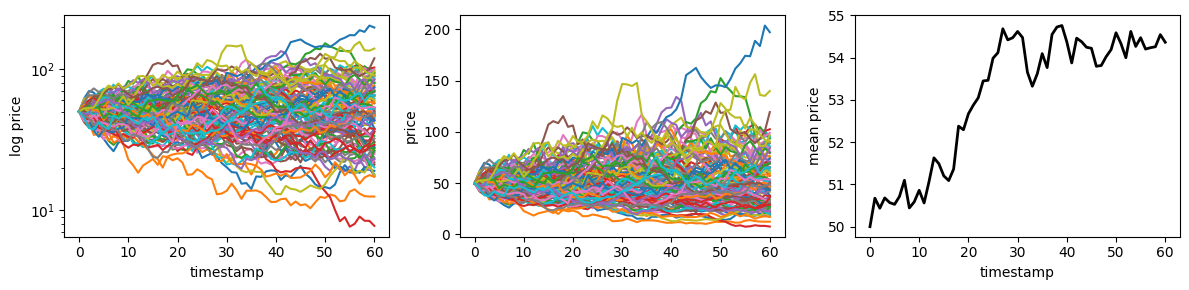

In [6]:
np.random.seed(101)
paths = simulate_gbm_paths(s0=50, num_paths=100, days=15)

fig, ax = plt.subplots(1, 3, figsize=(12, 3))
ax[0].plot(paths)
ax[0].set_yscale('log')
ax[0].set_xlabel('timestamp')
ax[0].set_ylabel('log price')
ax[1].plot(paths)
ax[1].set_xlabel('timestamp')
ax[1].set_ylabel('price')
ax[2].plot(np.mean(paths, axis=1), c='k', linewidth=2)
ax[2].set_xlabel('timestamp')
ax[2].set_ylabel('mean price')
plt.tight_layout()
plt.show()

In [7]:
df = get_df()
df = calc_evs(df)
df = calc_deltas(df)

In [8]:
def set_position(x):
    if x['EV'] > x['ap']:
        return x['av']
    elif x['EV'] < x['bp']:
        return -x['bv']
    else:
        return 0

df['position'] = df.apply(set_position, axis=1)
df

,bv,bp,ap,av,EV,delta,position
name,,,,,,,
AC_50_P,50,12,12.05,50,12.048494,-0.380611,0
AC_50_C,50,12,12.05,50,11.912658,0.616672,-50
AC_35_P,50,4.33,4.35,50,4.340086,-0.187301,0
AC_40_P,50,6.5,6.55,50,6.517882,-0.252433,0
AC_45_P,50,9.05,9.1,50,9.103329,-0.316967,50
AC_60_C,50,8.8,8.85,50,8.687031,0.500993,-50
AC_50_P_2,50,9.7,9.75,50,9.873165,-0.401554,50
AC_50_C_2,50,9.7,9.75,50,9.816017,0.597303,50
AC_50_CO,50,22.2,22.3,50,21.785823,0.215118,-50


In [9]:
def calc_edge(x):
    if x['position'] > 0:
        return x['EV'] - x['ap']
    elif x['position'] < 0:
        return x['bp'] - x['EV']

df = df[df['position'] != 0]
df['edge'] = df.apply(calc_edge, axis=1)

# Conservative, not considering opposing bets cancel delta and reduce spread cost. Only for filtering.
df.loc[:, 'net_edge'] = df['edge'] - abs(df['delta']) * 0.025  # Considering underlying spread cost

df

,bv,bp,ap,av,EV,delta,position,edge,net_edge
name,,,,,,,,,
AC_50_C,50,12,12.05,50,11.912658,0.616672,-50,0.087342,0.071925
AC_45_P,50,9.05,9.1,50,9.103329,-0.316967,50,0.003329,-0.004596
AC_60_C,50,8.8,8.85,50,8.687031,0.500993,-50,0.112969,0.100444
AC_50_P_2,50,9.7,9.75,50,9.873165,-0.401554,50,0.123165,0.113126
AC_50_C_2,50,9.7,9.75,50,9.816017,0.597303,50,0.066017,0.051084
AC_50_CO,50,22.2,22.3,50,21.785823,0.215118,-50,0.414177,0.408799
AC_40_BP,50,5,5.1,50,4.7857,-0.16,-50,0.214300,0.2103
AC_45_KO,500,0.15,0.175,500,0.209407,0.031665,500,0.034407,0.033616


In [10]:
def calc_position_delta(x):
    if x['position'] > 0:
        return x['av'] * x['delta']
    elif x['position'] < 0:
        return -x['bv'] * x['delta']

df = df[df['net_edge'] > 0]
df['position_delta'] = df.apply(calc_position_delta, axis=1)
df

,bv,bp,ap,av,EV,delta,position,edge,net_edge,position_delta
name,,,,,,,,,,
AC_50_C,50,12,12.05,50,11.912658,0.616672,-50,0.087342,0.071925,-30.833591
AC_60_C,50,8.8,8.85,50,8.687031,0.500993,-50,0.112969,0.100444,-25.049669
AC_50_P_2,50,9.7,9.75,50,9.873165,-0.401554,50,0.123165,0.113126,-20.077716
AC_50_C_2,50,9.7,9.75,50,9.816017,0.597303,50,0.066017,0.051084,29.865136
AC_50_CO,50,22.2,22.3,50,21.785823,0.215118,-50,0.414177,0.408799,-10.755875
AC_40_BP,50,5,5.1,50,4.7857,-0.16,-50,0.214300,0.2103,8.000000
AC_45_KO,500,0.15,0.175,500,0.209407,0.031665,500,0.034407,0.033616,15.832418


In [11]:
print(f"Total delta: {df['position_delta'].sum()}")

ac_position = -df['position_delta'].sum().round()
print(f"Underlying (AC) position: {int(ac_position)}")

Total delta: -33.01929801843767
Underlying (AC) position: 33


In [12]:
df.loc[:, 'pnl'] = df['edge'] * df['position'].abs() * 3000  # Contract size is 3000
pnl = df['pnl'].sum() - abs(ac_position) * 0.025 * 3000
print(f"Expected PnL: {round(pnl)} XIRECs")

Expected PnL: 201831 XIRECs
